# Plotting Distribution Laws:   
The different distribution laws describes how particles occupy different energy levels in a system.  

1. Maxwell Boltzmann Distribution Law :  
* For distinguishable, identical particles of any spin
* e.g. molecules of a gas

$$
f(E) = \frac{1}{e^{(\frac{E-\mu}{kT})}}
$$

2. Bose Einstein Distribution Law:
* For indistinguishable, identical particles of zeo or integral spin
* Particles described by symmetric wave function
* Particles do not obey Pauli exclusion principle
* e.g. photon, phonons and $\alpha$-particle

$$
f(E) = \frac{1}{e^{(\frac{E-\mu}{kT})}-1}
$$

3. Fermi Dirac Distribution Law:
* For indistinguishable, identical particles of half integral spin
* Particles described by assymmetric wave function
* Particles obey Pauli exclusion principle
* e.g. $e^-$ , $p^+$ and $n^0$

$$
f(E) = \frac{1}{e^{(\frac{E-\mu}{kT})}+1}
$$

where  
$E$ is energy  
$\mu$ is the chemical potential  
$k$ is Boltzmann constant  
$T$ is absolte temperature

In [1]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.constants import k

In [2]:
#constants
u = 0  #chemical potential in eV
e = 1.6e-19  #magnitude of charge of electron
a = {0 : "Maxwell Boltzmann Distribution", 
     -1 : "Bose Einstein Distribution" , 
     1 : "Fermi Dirac Distribution"}

In [3]:
#inputs for f
E = np.linspace(-0.5,0.5,1000)  #energy in eV
#E = np.delete(E,0)  #removing E=0 to prevent division by zero
T = np.linspace(100,1100,5)  #temperature in K

In [4]:
#distribution function
def f(E,T,a):
    x = (E-u)*e/(k*T)
    if x > 100:
        return np.exp(-x)  #applying approximation as e^100 > > 1
    else:
        return 1 / (np.exp(x) + a)

In [5]:
#calculating distribution function values
data = {}
for a0 in a.keys():
    data_a = {}
    for temp in T:
        data_t = []
        for energy in E:
            data_t.append(f(energy, temp, a0))
        data_a[temp] = data_t
    data[f"{a[a0]}"] = data_a

for temp in T:
    data['Bose Einstein Distribution'][temp][500] = np.nan #removing infinity term in Bose Einstein Distribution

In [ ]:
print(data)

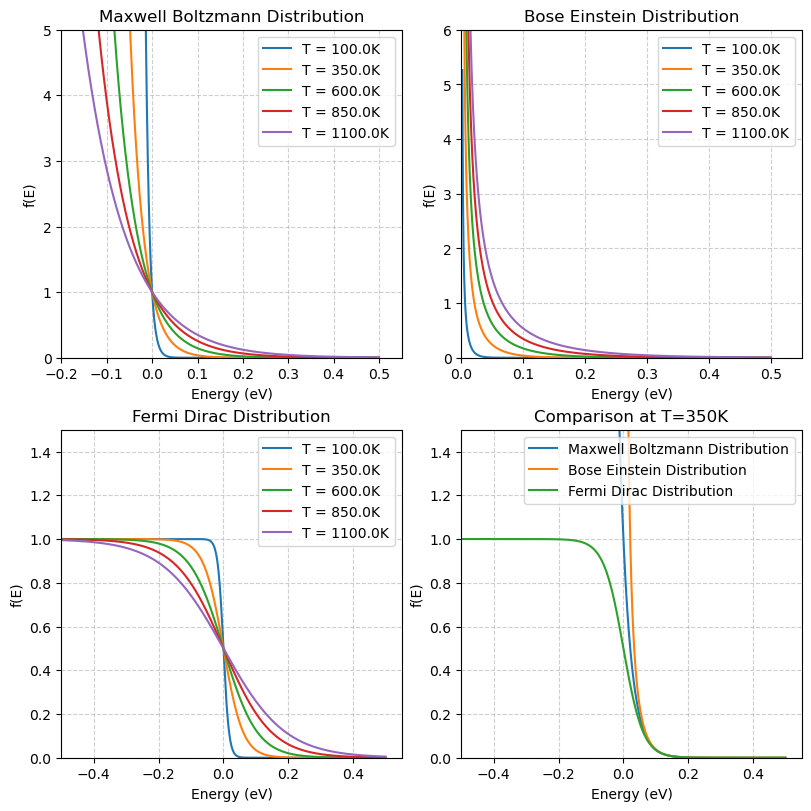

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8), constrained_layout=True)
axes = axes.flatten()  #make it one 1D for easy looping

#individual distribution law plots
for i, ax in enumerate(axes):
    for temp in T:
        ax.plot(E, data[list(data.keys())[i]][temp], label=f'T = {temp}K')
    if i==2:
        break

#for temp in T:
#    axes[0,1].plot(E, data[list(data.keys())[1]][temp], label=f'T = {temp}K')

#for temp in T:
#    axes[1,0].plot(E, data[list(data.keys())[2]][temp], label=f'T = {temp}K')
    
#comparison of distribution laws plot
t0 = 350
for i in range(3):
    ds_law = list(data.keys())[i]
    axes[3].plot(E, data[ds_law][t0], label=f'{ds_law}')
    
#subplots formatting
x_lim = [-0.2, -0, -0.5, -0.5]
y_lim = [5, 6, 1.5, 1.5]
i=0
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.6)       # Enable grid
    ax.set_xlabel("Energy (eV)")                 # Common X label
    ax.set_ylabel("f(E)")                        # Common Y label
    if i<3: ax.set_title(f"{list(data.keys())[i]}")       #title
    else : ax.set_title(f"Comparison at T={t0}K")
    ax.tick_params(axis='both', labelsize=10)      # Tick label size
    ax.set_xlim(x_lim[i])                             # X-axis range
    ax.set_ylim(0,y_lim[i])                             # Y-axis range
    ax.legend()
    i+=1

plt.show()